# WT channel-core RMSF comparison

Here we compare the final allOK3 WT ensembles for $\mathrm{K}_{\mathrm{V}}2.1$, $\mathrm{Na}_{\mathrm{V}}1.5$, and $\mathrm{Ca}_{\mathrm{V}}1.2$. Each channel is shown as a paired vanilla-versus-masked profile using the project-wide WT color palette. For $\mathrm{Na}_{\mathrm{V}}1.5$, **masked** denotes the original mask used in the main analysis; alternative mask profiles remain supplementary.

Only the channel-core display window is plotted. $\mathrm{K}_{\mathrm{V}}2.1$ uses a continuous S1–S6-centered window spanning channel residues 168–438, preserving the short flanks and connecting loops needed to read the channel core as one sequence profile while excluding the long terminal regions. The four-domain $\mathrm{Na}_{\mathrm{V}}1.5$ and $\mathrm{Ca}_{\mathrm{V}}1.2$ windows retain 30-residue flanks around their first and last mapped transmembrane segments. These are plotting selections, not new model-level QC filters, and omission should not be interpreted as proof that every excluded residue is intrinsically disordered.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'shared').is_dir())
sys.path.insert(0, str(repo_root))

from shared.cross_channel_rmsf import (
    CHANNEL_NAMES, CHANNEL_ORDER, CORE_WINDOWS,
    load_wt_core_profiles, summarize_wt_core_profiles,
    plot_wt_core_profiles, plot_wt_core_bar_profiles,
    plot_wt_core_delta_profiles,
)

figures = repo_root / 'docs' / 'figures' / 'cross_channel_wt_rmsf'
profiles = load_wt_core_profiles(repo_root)
summary = summarize_wt_core_profiles(profiles)

window_table = summary[['channel', 'channel_residue_window', 'raw_model_window']].drop_duplicates().reset_index(drop=True)
source_table = []
for channel in CHANNEL_ORDER:
    frame = profiles[channel]
    source_table.append({
        'channel': CHANNEL_NAMES[channel],
        'profile': frame.source_profile.iloc[0],
        'residues displayed per protocol': frame.raw_residue_number.nunique(),
    })
display(window_table)
display(__import__('pandas').DataFrame(source_table))

,channel,channel_residue_window,raw_model_window
0,Kv2.1,168–438,170–440
1,Nav1.5,417–1801,101–1485
2,Cav1.2,95–1554,95–1554


,channel,profile,residues displayed per protocol
0,Kv2.1,kv21/dataRMSF/profiles/kv21_all_ok_3_symmetry_...,271
1,Nav1.5,nav15/dataRMSF/profiles/nav15_all_ok_3_per_res...,1385
2,Cav1.2,cav12/dataRMSF/profiles/cav12_all_ok_3_per_res...,1460


## RMSF profiles

For residue $j$, ensemble RMSF is

$$\mathrm{RMSF}_j = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left\|\mathbf{r}_{ij}-\overline{\mathbf{r}}_j\right\|^2},$$

where $\mathbf{r}_{ij}$ is the aligned Cα coordinate of residue $j$ in model $i$, $\overline{\mathbf{r}}_j$ is its ensemble-mean coordinate, and $N$ is the number of retained allOK3 models in which that residue is resolved. RMSF therefore reports positional dispersion across an ensemble; the filled area follows the RMSF magnitude and is not a confidence interval.

All three rows use the same vertical scale. Yellow shading marks residues whose homologous MSA information was directly replaced by X in the masked protocol. The structural strip identifies the sequence-mapped transmembrane segments.

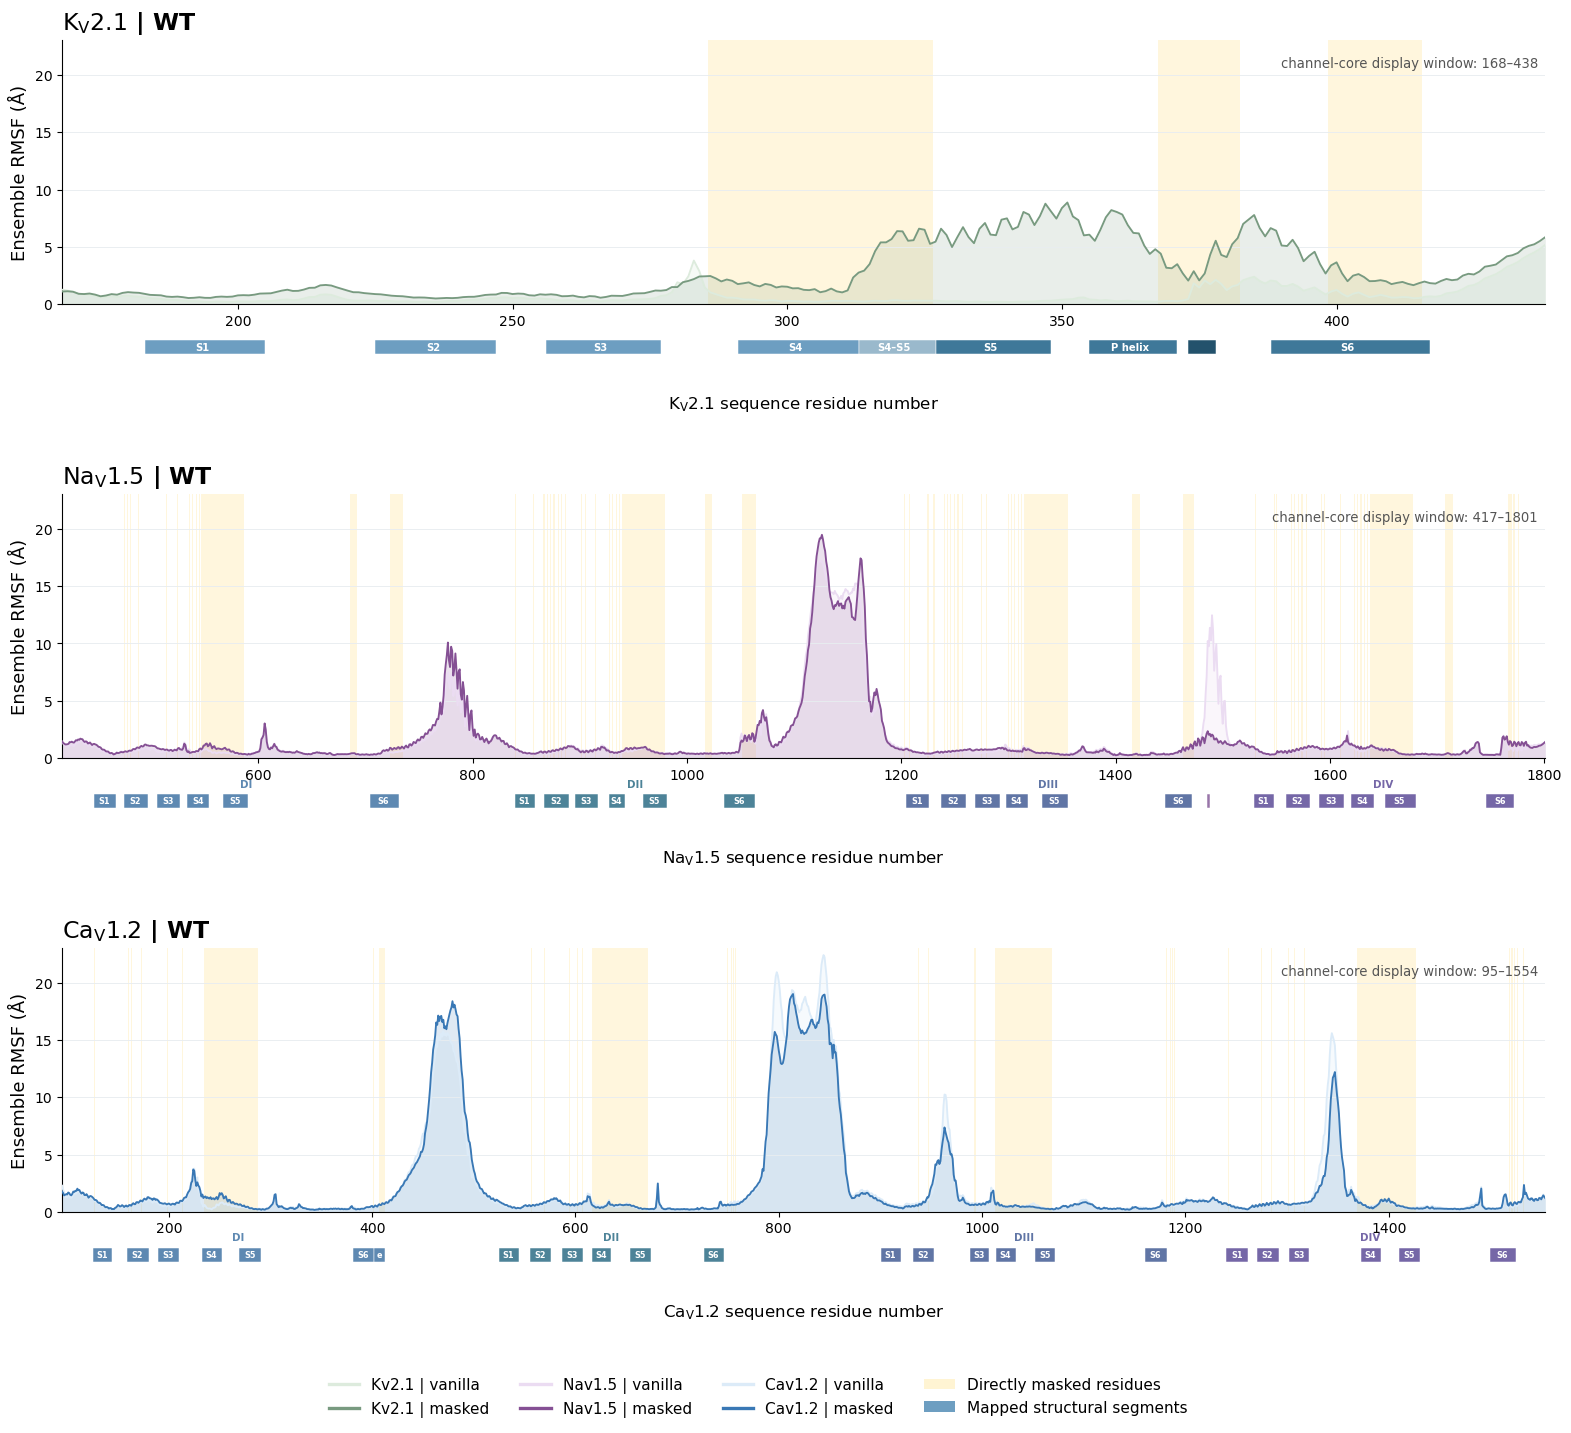

In [2]:
profile_figure = plot_wt_core_profiles(
    profiles,
    figures / 'wt_channel_core_rmsf_profiles.png',
)
display(profile_figure)
plt.close(profile_figure)

## Residue-wise bar profiles

This alternate rendering shows the same RMSF values as adjacent residue-wise bars. It is useful when the filled line profiles visually merge nearby peaks. Vanilla and masked bars are offset slightly at each residue; bar height is the RMSF value, not an uncertainty interval. For the four-domain channels, the structural track now labels each S1–S6 segment and groups the segments by domain (DI–DIV). In the CaV1.2 DI track, `e` denotes the short structure-guided S6 extension immediately following the mapped S6 core.

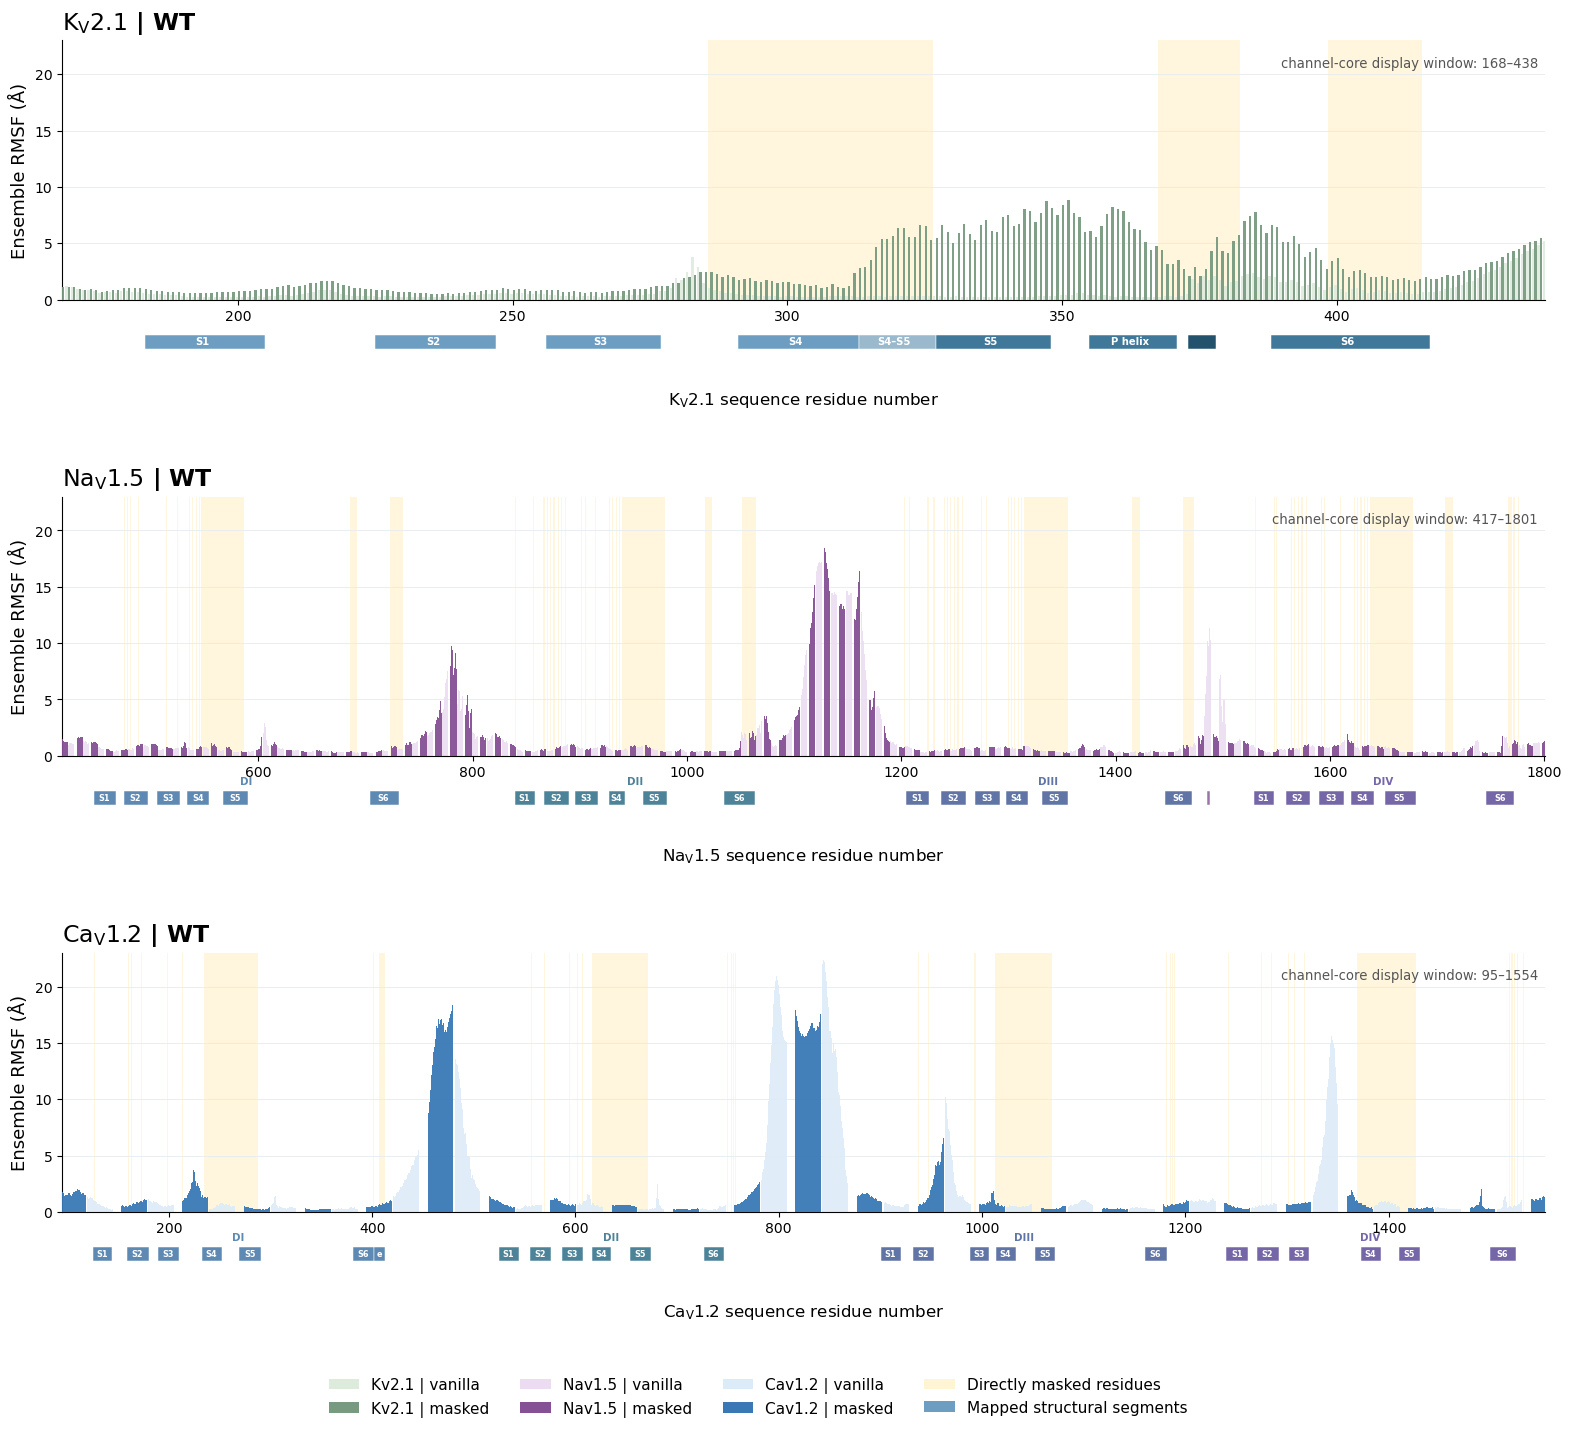

In [3]:
bar_figure = plot_wt_core_bar_profiles(
    profiles,
    figures / 'wt_channel_core_rmsf_bars.png',
)
display(bar_figure)
plt.close(bar_figure)

## Paired masking effect

The difference profile is calculated residue by residue as

$$\Delta\mathrm{RMSF}_j = \mathrm{RMSF}_{j,\,\mathrm{masked}} - \mathrm{RMSF}_{j,\,\mathrm{vanilla}}.$$

Positive values indicate greater positional dispersion in the masked WT ensemble; negative values indicate reduced dispersion. Because the comparison is paired by residue, broad downstream changes can be distinguished from effects confined to the directly masked sequence blocks.

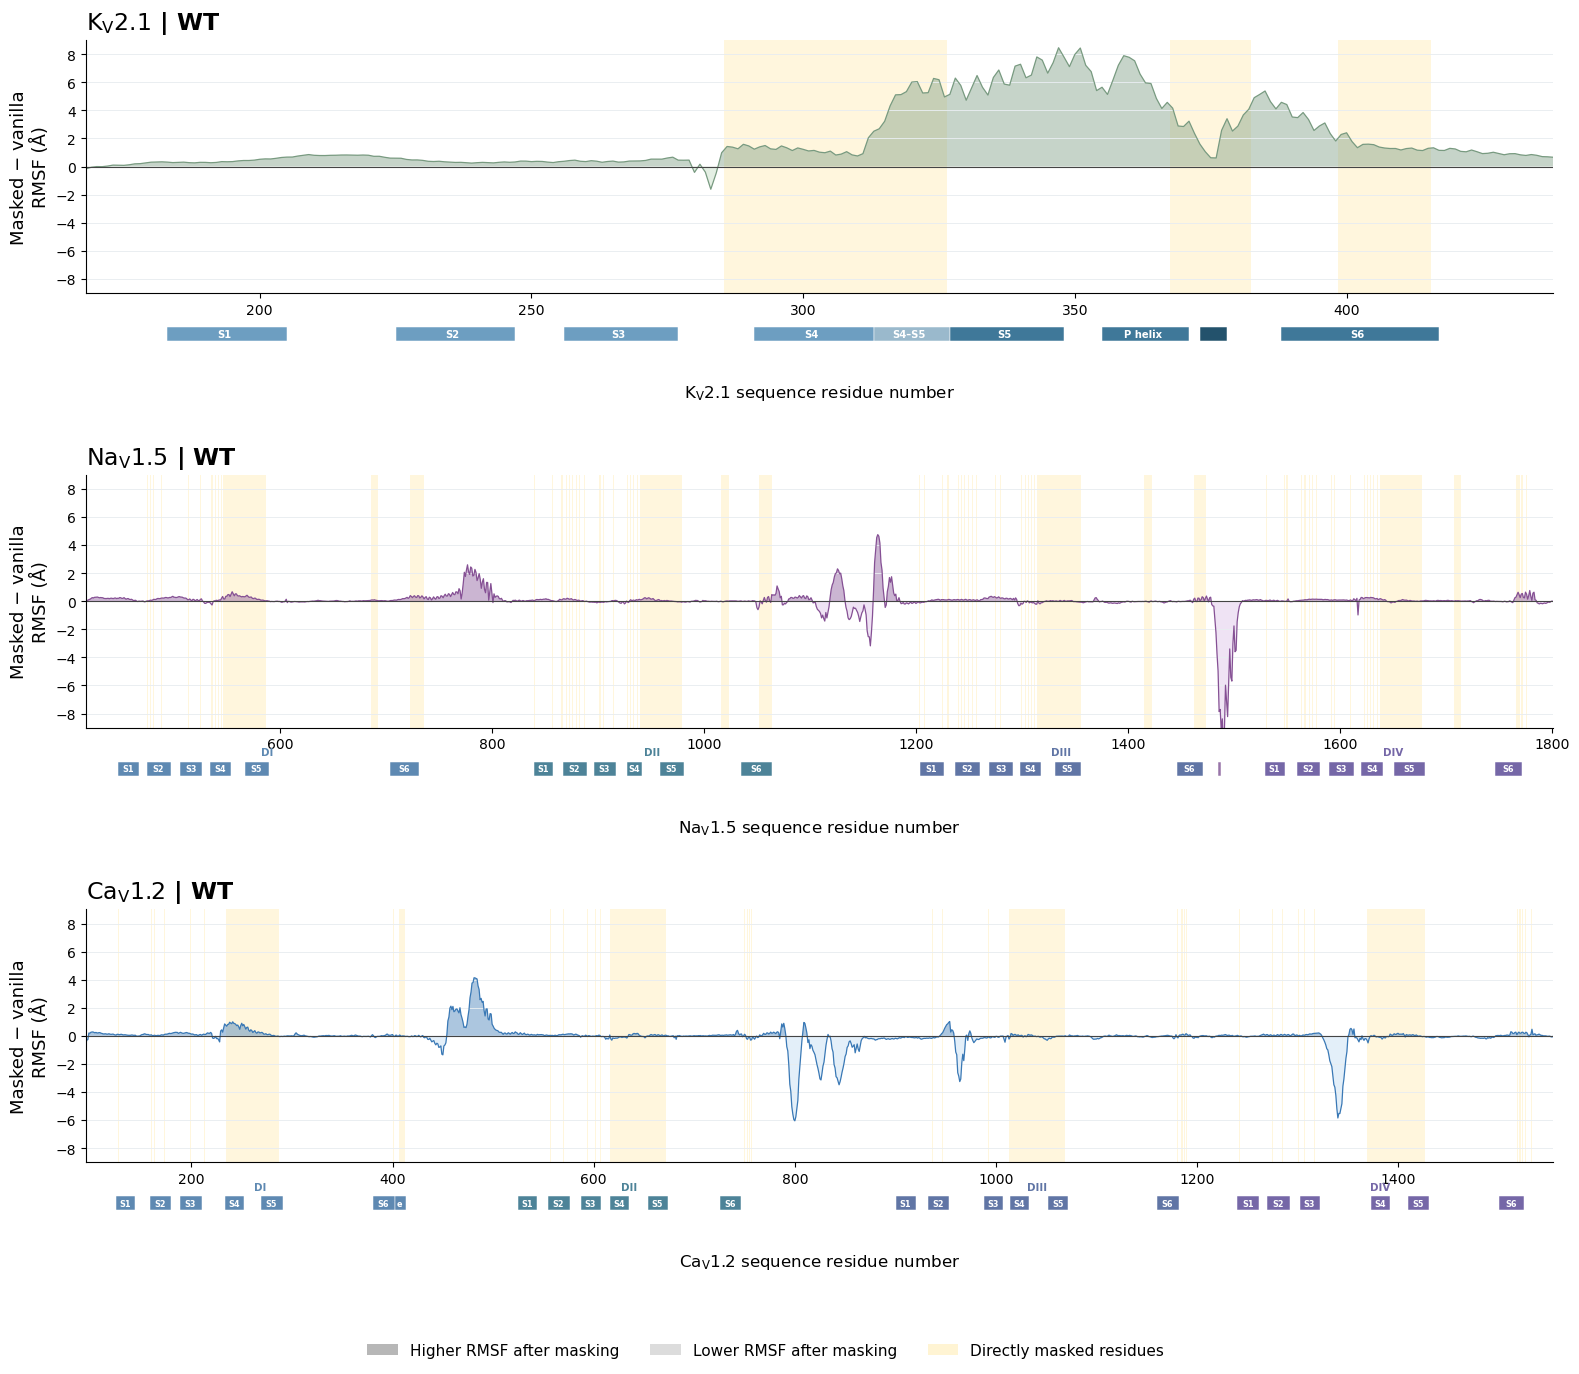

In [4]:
delta_figure = plot_wt_core_delta_profiles(
    profiles,
    figures / 'wt_channel_core_rmsf_delta.png',
)
display(delta_figure)
plt.close(delta_figure)

## Residue-wise summary

These statistics summarize the displayed core windows rather than the omitted terminal regions. The fraction increased is the proportion of raw residue positions with $\Delta\mathrm{RMSF}>0$; it does not count independent models and should be reported as a descriptive spatial summary rather than a formal significance test.

In [5]:
display(summary.round({
    'median_rmsf_A': 3,
    'mean_rmsf_A': 3,
    'p90_rmsf_A': 3,
    'p95_rmsf_A': 3,
    'median_masked_minus_vanilla_A': 3,
    'fraction_residues_increased_by_masking': 3,
}))

,channel,channel_residue_window,raw_model_window,protocol,residues,median_rmsf_A,mean_rmsf_A,p90_rmsf_A,p95_rmsf_A,median_masked_minus_vanilla_A,fraction_residues_increased_by_masking
0,Kv2.1,168–438,170–440,vanilla,271,0.414,0.760,1.782,2.419,0.926,0.970
1,Kv2.1,168–438,170–440,masked,271,1.804,2.819,6.590,7.481,0.926,0.970
2,Nav1.5,417–1801,101–1485,vanilla,1385,0.631,1.547,2.896,7.254,0.039,0.661
3,Nav1.5,417–1801,101–1485,masked,1385,0.733,1.572,2.486,7.479,0.039,0.661
4,Cav1.2,95–1554,95–1554,vanilla,1460,0.652,2.188,6.142,15.006,-0.002,0.492
5,Cav1.2,95–1554,95–1554,masked,1460,0.680,2.118,5.413,14.672,-0.002,0.492
